[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/key/lecture_3.2/lecture_3.2_Group_A.ipynb)

_Run this notebook in the browser — no install needed._

# Data from Lesson 3.1, for 3.2
## Analyze and plot the data we collected

**Instructor sequence:** Project and run the data cell below, then stop at the prediction prompt.
After students have predicted and sketched, scroll down to reveal the plotting cell and run it.
Run cells individually so the graph appears only after the prediction pause.

These are **already binned counts pooled across three lectures**, not individual heights.
Each entry in `group_a_game` is the number of Group A students in the corresponding four-inch height bin.


In [62]:
# Checked course-wide Group A game tally, from shortest to tallest height bin.
bin_left_edges = [52, 56, 60, 64, 68, 72, 76, 80, 84]
group_a_game_001 = [0, 3, 5, 6, 7, 1, 0, 0, 0,]
group_b_game_001 = [0, 0, 3, 11, 3, 3, 0, 0, 0]
group_a_game = [0, 3, 19, 19, 20, 7, 0, 0, 0]
bin_width = 4


### Compute mean and standard deviation

We get the counts for each bin by multiplying the bin centers by the number of people in the bin (variable is called weights)

In [63]:
import numpy as np

# Choose which tally to analyze and plot.
# current_data = group_a_game_001
# plot_title = "Group A (OO1) game"
current_data = group_b_game_001
plot_title = "Group B (001) game"

# Each count is a weight on the center of its four-inch height bin.
bin_centers = np.array(bin_left_edges) + bin_width / 2
weights = np.array(current_data)

data_mean = np.average(bin_centers, weights=weights)
data_std = np.sqrt(np.average((bin_centers - data_mean) ** 2, weights=weights))

print(f"Mean: {data_mean:.1f}")
print(f"Standard deviation: {data_std:.1f}")


Mean: 67.2
Standard deviation: 3.6


### Pause: predict before plotting

**Which four-inch height interval will have the tallest bar?**

The entries are student counts. Match each count to the bin beginning at the same position in `bin_left_edges`.

---
### The cell below does the basic plotting


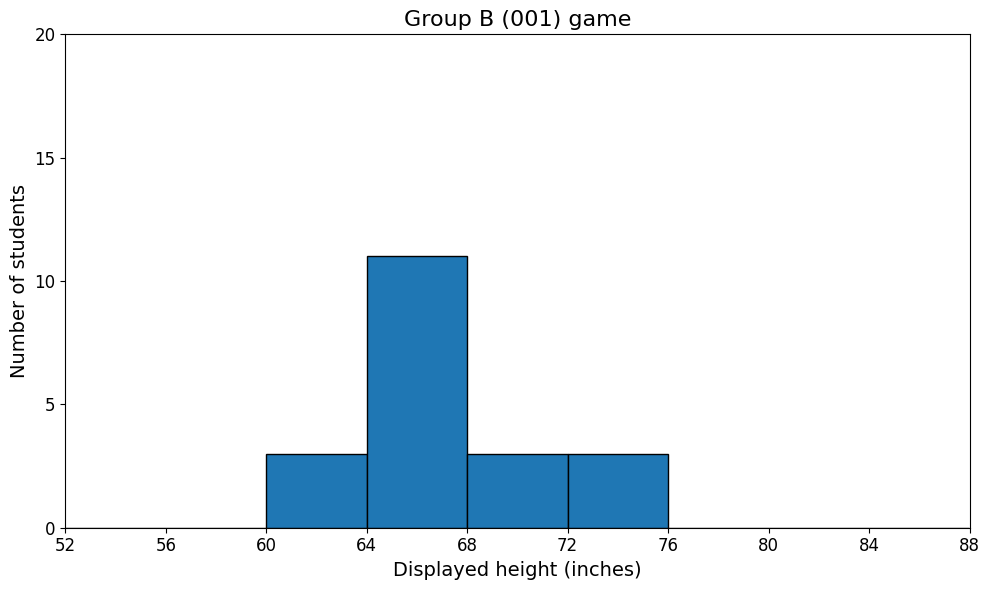

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(
    bin_left_edges,
    current_data,
    width=bin_width,
    align="edge",
    edgecolor="black"
)
plt.xlabel("Displayed height (inches)", fontsize=14)
plt.ylabel("Number of students", fontsize=14)
plt.title(plot_title, fontsize=16)
plt.xticks(bin_left_edges + [bin_left_edges[-1] + bin_width], fontsize=12)
plt.yticks(range(0, max(group_a_game) + 1, 5), fontsize=12)
plt.xlim(bin_left_edges[0], bin_left_edges[-1] + bin_width)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


### Add mean and standard deviation to the plot

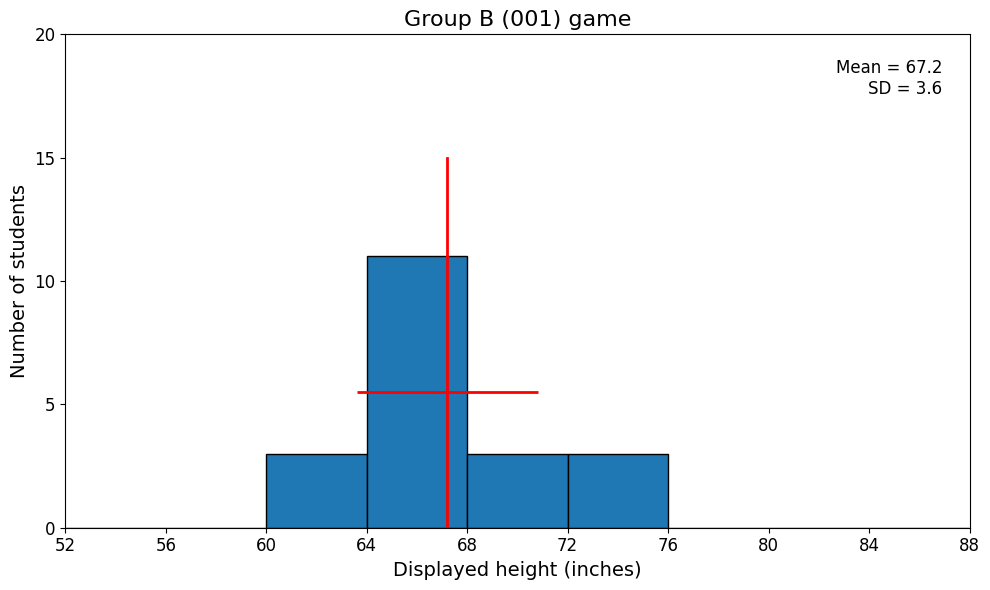

In [65]:
plt.figure(figsize=(10, 6))
plt.bar(
    bin_left_edges,
    current_data,
    width=bin_width,
    align="edge",
    edgecolor="black"
)

# Fixed y-axis top at the pooled Group A data max.
y_top = max(group_a_game)

# Red vertical line at the mean, rising to 3/4 of the y-axis limit.
plt.plot([data_mean, data_mean], [0, 0.75 * y_top], color="red", linewidth=2)

# Red horizontal line spanning mean +/- 1 SD.
sd_line_y = max(current_data) / 2
plt.hlines(sd_line_y, data_mean - data_std, data_mean + data_std,
          color="red", linewidth=2)

# Summary text in the upper right.
plt.text(0.97, 0.95, f"Mean = {data_mean:.1f}\nSD = {data_std:.1f}",
        transform=plt.gca().transAxes, ha="right", va="top", fontsize=12)

plt.xlabel("Displayed height (inches)", fontsize=14)
plt.ylabel("Number of students", fontsize=14)
plt.title(plot_title, fontsize=16)
plt.xticks(bin_left_edges + [bin_left_edges[-1] + bin_width], fontsize=12)
plt.yticks(range(0, max(group_a_game) + 1, 5), fontsize=12)
plt.xlim(bin_left_edges[0], bin_left_edges[-1] + bin_width)
plt.ylim(0, y_top)
plt.tight_layout()
plt.show()


### Convert x axis values to z-scores

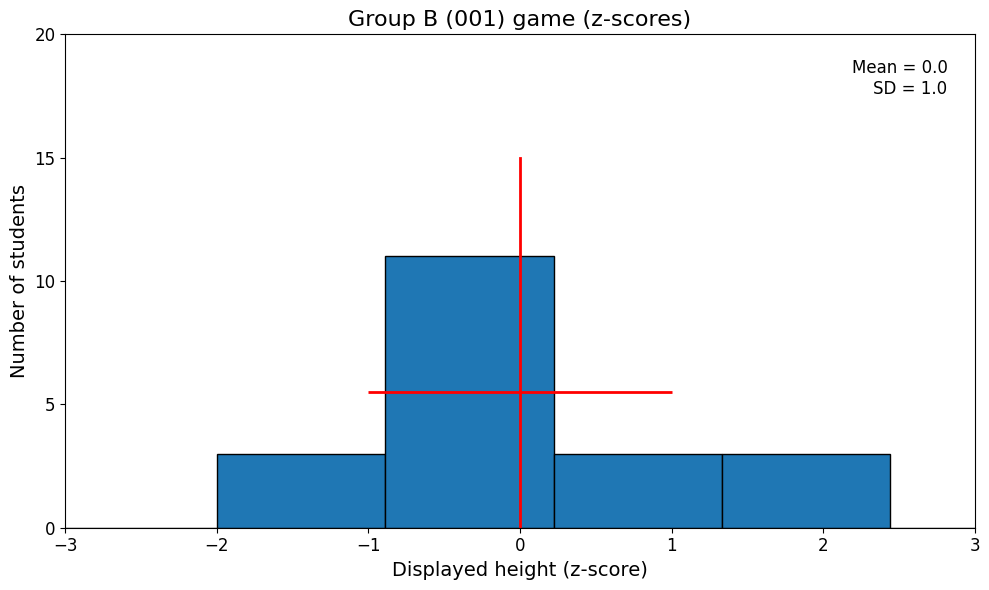

In [66]:
# Convert the bin centers to z-scores: z = (height - mean) / SD.
z_centers = (bin_centers - data_mean) / data_std
z_bin_width = bin_width / data_std

plt.figure(figsize=(10, 6))
plt.bar(
    z_centers,
    current_data,
    width=z_bin_width,
    align="center",
    edgecolor="black"
)

# Fixed y-axis top at the pooled Group A data max.
y_top = max(group_a_game)

# After the z-score conversion the mean is 0 and one SD is one unit.
plt.plot([0, 0], [0, 0.75 * y_top], color="red", linewidth=2)
plt.hlines(max(current_data) / 2, -1, 1, color="red", linewidth=2)

# Summary text in the upper right.
plt.text(0.97, 0.95, "Mean = 0.0\nSD = 1.0",
        transform=plt.gca().transAxes, ha="right", va="top", fontsize=12)

plt.xlabel("Displayed height (z-score)", fontsize=14)
plt.ylabel("Number of students", fontsize=14)
plt.title(plot_title + " (z-scores)", fontsize=16)
plt.xticks(range(-3, 4), fontsize=12)
plt.yticks(range(0, max(group_a_game) + 1, 5), fontsize=12)
plt.xlim(-3, 3)
plt.ylim(0, y_top)
plt.tight_layout()
plt.show()


### Overlay the standard normal

Scale the standard normal curve to expected counts: `N * bin_width_in_z * (1 / sqrt(2*pi)) * exp(-z**2 / 2)`, where `N` is the total number of students.

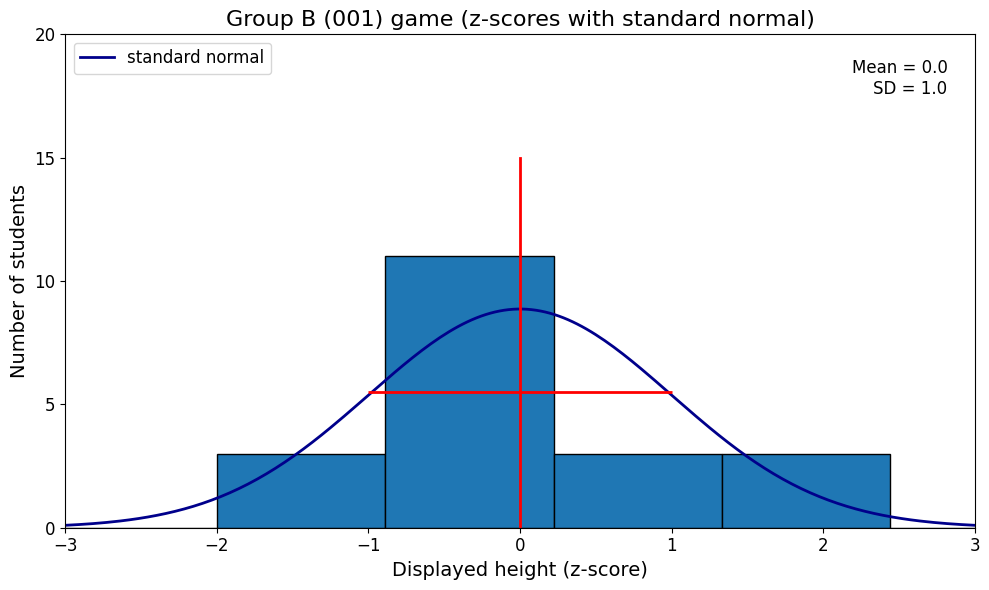

In [67]:
# Convert the bin centers to z-scores: z = (height - mean) / SD.
z_centers = (bin_centers - data_mean) / data_std
z_bin_width = bin_width / data_std

plt.figure(figsize=(10, 6))
plt.bar(
    z_centers,
    current_data,
    width=z_bin_width,
    align="center",
    edgecolor="black"
)

# Standard normal, scaled to expected counts for these bins.
n_total = sum(current_data)
z_grid = np.linspace(-3, 3, 200)
normal_counts = n_total * z_bin_width * np.exp(-z_grid ** 2 / 2) / np.sqrt(2 * np.pi)
plt.plot(z_grid, normal_counts, color="darkblue", linewidth=2, label="standard normal")

# Fixed y-axis top at the pooled Group A data max.
y_top = max(group_a_game)

# After the z-score conversion the mean is 0 and one SD is one unit.
plt.plot([0, 0], [0, 0.75 * y_top], color="red", linewidth=2)
plt.hlines(max(current_data) / 2, -1, 1, color="red", linewidth=2)

# Summary text in the upper right.
plt.text(0.97, 0.95, "Mean = 0.0\nSD = 1.0",
        transform=plt.gca().transAxes, ha="right", va="top", fontsize=12)

plt.xlabel("Displayed height (z-score)", fontsize=14)
plt.ylabel("Number of students", fontsize=14)
plt.title(plot_title + " (z-scores with standard normal)", fontsize=16)
plt.xticks(range(-3, 4), fontsize=12)
plt.yticks(range(0, max(group_a_game) + 1, 5), fontsize=12)
plt.xlim(-3, 3)
plt.ylim(0, y_top)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


### Statistical test of mean difference between Group A and Group B in Section 001.  Not statistically significant.

In [68]:
from scipy import stats

# Rebuild individual heights from the binned counts: repeat each bin center
# once per student counted in that bin.
group_a_heights = np.repeat(bin_centers, group_a_game_001)
group_b_heights = np.repeat(bin_centers, group_b_game_001)

t_stat, p_value = stats.ttest_ind(group_a_heights, group_b_heights, equal_var=True)

print(f"Group A: n = {group_a_heights.size}, mean = {group_a_heights.mean():.1f}")
print(f"Group B: n = {group_b_heights.size}, mean = {group_b_heights.mean():.1f}")
print(f"t = {t_stat:.2f}")
print(f"p = {p_value:.3f}")


Group A: n = 22, mean = 65.6
Group B: n = 20, mean = 67.2
t = -1.21
p = 0.235
